# Problem 2

Here, we will use Python, NumPy, and Matplotlib to estimate the rocket's velocity and acceleration using finite-difference formulas with truncation error of $O(h^2)$.
The results are then shown using three plots: altitude vs. time, velocity vs. time, and acceleration vs. time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

The given time and altitude data are:

In [ ]:
t_values = np.array(
    [
        0,
        2,
        4,
        6,
        8,
        10,
        12,
        14,
        16,
        18,
        20,
        22,
        24,
        26,
        28,
        30,
    ],
    dtype=float,
)
L_values = np.array(
    [
        0,
        80,
        350,
        965,
        1400,
        2100,
        3100,
        4435,
        5300,
        6500,
        8215,
        9300,
        10700,
        12200,
        13635,
        15300,
    ],
    dtype=float,
)

h_values = np.diff(t_values)
h = h_values[0]

if not np.allclose(h_values, h):
    raise ValueError(
        "Time spacing is not uniform. O(h^2) finite-difference formulas here assume constant h."
    )

print(f"Uniform time spacing confirmed: h = {h:.1f} s")

Uniform time spacing confirmed: h = 2.0 s


## a) Velocity and Acceleration using $O(h^2)$ Finite Differences
For velocity $v = dL/dt$:
- At the first point, use forward one-sided formula: $v_0 \approx \frac{-3L_0 + 4L_1 - L_2}{2h}$
- At interior points, use central difference: $v_i \approx \frac{L_{i+1} - L_{i-1}}{2h}$
- At the last point, use backward one-sided formula: $v_n \approx \frac{3L_n - 4L_{n-1} + L_{n-2}}{2h}$

For acceleration $a = d^2L/dt^2$:
- At the first point, use forward one-sided formula: $a_0 \approx \frac{2L_0 - 5L_1 + 4L_2 - L_3}{h^2}$
- At interior points, use central difference: $a_i \approx \frac{L_{i+1} - 2L_i + L_{i-1}}{h^2}$
- At the last point, use backward one-sided formula: $a_n \approx \frac{2L_n - 5L_{n-1} + 4L_{n-2} - L_{n-3}}{h^2}$

In [ ]:
def get_velocity_acceleration_oh2(
    t_values: np.ndarray, L_values: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Compute velocity and acceleration at all points using O(h^2) finite-difference formulas."""

    if len(t_values) != len(L_values):
        raise ValueError("t_values and L_values must have the same length.")
    if len(t_values) < 4:
        raise ValueError(
            "At least 4 data points are required for O(h^2) endpoint formulas."
        )

    h_values = np.diff(t_values)
    h = h_values[0]
    if not np.allclose(h_values, h):
        raise ValueError("Time spacing must be uniform for these formulae.")

    n = len(t_values)
    velocity = np.zeros(n, dtype=float)
    acceleration = np.zeros(n, dtype=float)

    # Velocity: O(h^2) one-sided at endpoints, central at interior points
    velocity[0] = (-3.0 * L_values[0] + 4.0 * L_values[1] - L_values[2]) / (2.0 * h)
    velocity[1:-1] = (L_values[2:] - L_values[:-2]) / (2.0 * h)
    velocity[-1] = (3.0 * L_values[-1] - 4.0 * L_values[-2] + L_values[-3]) / (2.0 * h)

    # Acceleration: O(h^2) one-sided at endpoints, central at interior points
    acceleration[0] = (
        2.0 * L_values[0] - 5.0 * L_values[1] + 4.0 * L_values[2] - L_values[3]
    ) / (h**2)
    acceleration[1:-1] = (L_values[2:] - 2.0 * L_values[1:-1] + L_values[:-2]) / (h**2)
    acceleration[-1] = (
        2.0 * L_values[-1] - 5.0 * L_values[-2] + 4.0 * L_values[-3] - L_values[-4]
    ) / (h**2)

    return velocity, acceleration

In [4]:
velocity_values, acceleration_values = get_velocity_acceleration_oh2(t_values, L_values)

print("(a) Finite-Difference Results with O(h^2) Truncation Error")
print("=" * 95)
print(f"{'t (s)':>8}  {'L (ft)':>12}  {'v (ft/s)':>14}  {'a (ft/s^2)':>16}")
print("-" * 95)

for t_val, L_val, v_val, a_val in zip(
    t_values, L_values, velocity_values, acceleration_values
):
    print(f"{t_val:>8.1f}  {L_val:>12.1f}  {v_val:>14.3f}  {a_val:>16.3f}")

(a) Finite-Difference Results with O(h^2) Truncation Error
   t (s)        L (ft)        v (ft/s)        a (ft/s^2)
-----------------------------------------------------------------------------------------------
     0.0           0.0          -7.500             8.750
     2.0          80.0          87.500            47.500
     4.0         350.0         221.250            86.250
     6.0         965.0         262.500           -45.000
     8.0        1400.0         283.750            66.250
    10.0        2100.0         425.000            75.000
    12.0        3100.0         583.750            83.750
    14.0        4435.0         550.000          -117.500
    16.0        5300.0         516.250            83.750
    18.0        6500.0         728.750           128.750
    20.0        8215.0         700.000          -157.500
    22.0        9300.0         621.250            78.750
    24.0       10700.0         725.000            25.000
    26.0       12200.0         733.750         

## b) Plots

Now we plot altitude, velocity, and acceleration versus time. Here are some takeaways:

1. The altitude curve increases monotonically and becomes steeper with time, which indicates the rocket is continuously gaining altitude and speed.
2. The velocity values are mostly increasing, with larger values at later times, showing sustained upward motion and acceleration.
3. The acceleration values are generally positive over the interval, so the rocket keeps speeding up upward.
4. There are local fluctuations in acceleration due to measurement spacing and discrete finite-difference approximation, especially near boundaries where one-sided formulas are used.

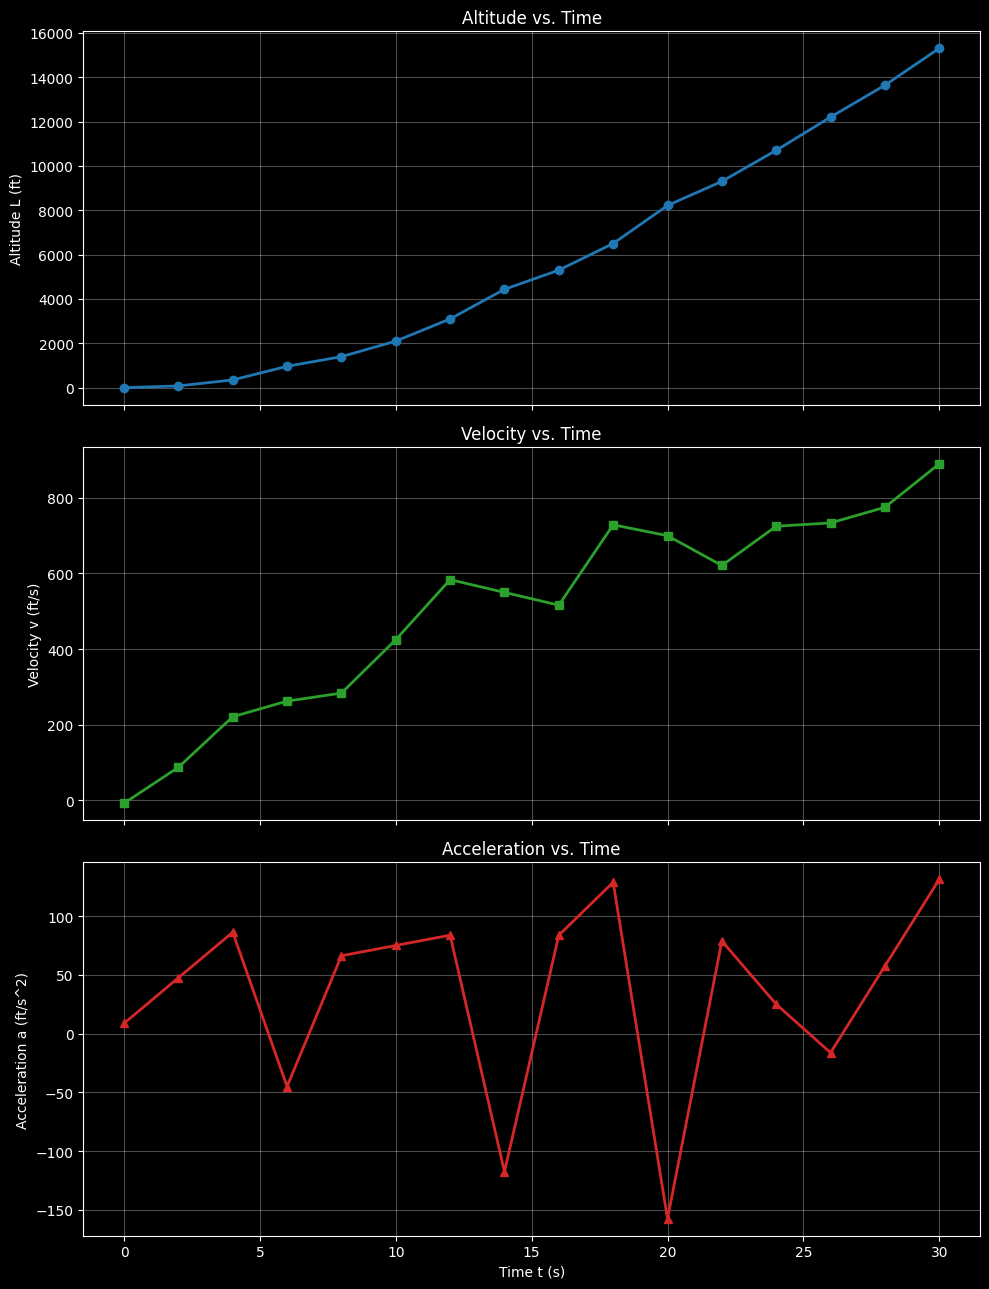

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 13), sharex=True)

# Altitude vs. Time
axes[0].plot(t_values, L_values, marker="o", linewidth=2.0, color="tab:blue")
axes[0].set_ylabel("Altitude L (ft)")
axes[0].set_title("Altitude vs. Time")
axes[0].grid(True, alpha=0.3)

# Velocity vs. Time
axes[1].plot(t_values, velocity_values, marker="s", linewidth=2.0, color="tab:green")
axes[1].set_ylabel("Velocity v (ft/s)")
axes[1].set_title("Velocity vs. Time")
axes[1].grid(True, alpha=0.3)

# Acceleration vs. Time
axes[2].plot(t_values, acceleration_values, marker="^", linewidth=2.0, color="tab:red")
axes[2].set_xlabel("Time t (s)")
axes[2].set_ylabel("Acceleration a (ft/s^2)")
axes[2].set_title("Acceleration vs. Time")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()